# 🥦 Vegetable Classification — CNN vs Transfer Learning

## STEP 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## STEP 2 — Copy Dataset to Local SSD (Fixes Slow Training)
>  This copies your data from Google Drive to Colab's fast local disk.
> Training will be **5–10x faster** after this step.
> Only needs to run once per session.

In [3]:
import os
import shutil

SRC = "/content/drive/MyDrive/Vegetable Images"
DST = "/content/VegetableImages"

if not os.path.exists(DST):
    print("Copying dataset to local SSD... (this takes ~1-2 minutes)")
    shutil.copytree(SRC, DST)
    print("Done! Dataset is now on local disk.")
else:
    print("Dataset already on local disk. Skipping copy.")

Dataset already on local disk. Skipping copy.


## STEP 3 — Import Libraries

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## STEP 4 — Dataset Paths & Parameters

In [5]:
# Paths — pointing to local SSD
TRAIN_DIR = "/content/VegetableImages/train"
VAL_DIR   = "/content/VegetableImages/validation"
TEST_DIR  = "/content/VegetableImages/test"

# Image parameters
IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
AUTOTUNE   = tf.data.AUTOTUNE

## STEP 5 — Load & Optimize Dataset Pipeline
> We create **two sets** of datasets:
> - `*_cnn` → normalized to [0,1] for the Simple CNN
> - `*_transfer` → preprocessed with MobileNetV2's own preprocessor (expects [0,255] scaled to [-1,1])

In [6]:
# ---------- Raw datasets (shared base) ----------
def load_raw(directory, shuffle=True):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle
    )

train_raw = load_raw(TRAIN_DIR,  shuffle=True)
val_raw   = load_raw(VAL_DIR,    shuffle=False)
test_raw  = load_raw(TEST_DIR,   shuffle=False)

# Capture class names before any transformations
class_names = train_raw.class_names
num_classes = len(class_names)
print(f"Classes ({num_classes}):", class_names)

# ---------- CNN datasets — normalize to [0, 1] ----------
def normalize(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_cnn = (train_raw
             .map(normalize, num_parallel_calls=AUTOTUNE)
             .cache()
             .shuffle(1000)
             .prefetch(AUTOTUNE))

val_cnn   = (val_raw
             .map(normalize, num_parallel_calls=AUTOTUNE)
             .cache()
             .prefetch(AUTOTUNE))

test_cnn  = (test_raw
             .map(normalize, num_parallel_calls=AUTOTUNE)
             .prefetch(AUTOTUNE))

# ---------- Transfer Learning datasets — MobileNetV2 preprocess (scales to [-1, 1]) ----------
def mobilenet_preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)   # MobileNetV2 expects this, NOT /255
    return image, label

train_transfer = (train_raw
                  .map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
                  .cache()
                  .shuffle(1000)
                  .prefetch(AUTOTUNE))

val_transfer   = (val_raw
                  .map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
                  .cache()
                  .prefetch(AUTOTUNE))

test_transfer  = (test_raw
                  .map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
                  .prefetch(AUTOTUNE))

print("Datasets ready!")

Found 15000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Found 3000 files belonging to 15 classes.
Classes (15): ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Datasets ready!


## STEP 6 — Preview Sample Images

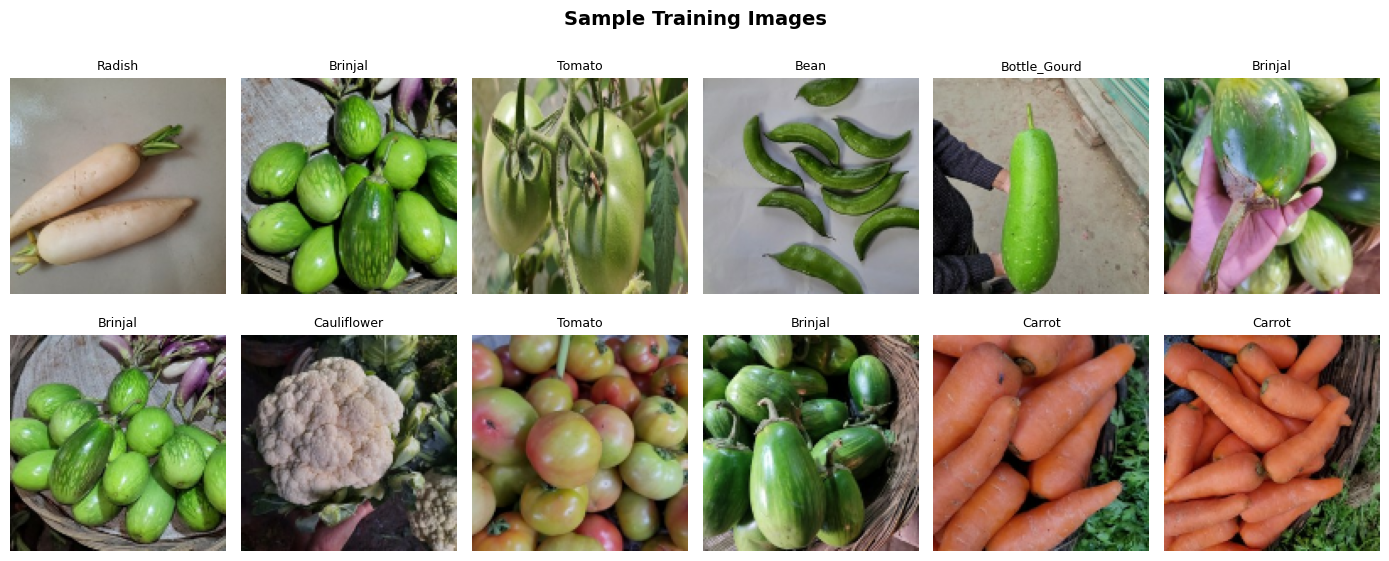

In [7]:
plt.figure(figsize=(14, 6))
for images, labels in train_cnn.take(1):
    for i in range(12):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 7 — Common Callbacks

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

cnn_checkpoint = ModelCheckpoint(
    "/content/best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

transfer_checkpoint = ModelCheckpoint(
    "/content/best_transfer_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

## STEP 8 — Build Simple CNN Model

In [9]:
cnn_model = models.Sequential([
    # Input
    layers.Input(shape=(128, 128, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Classifier head
    layers.GlobalAveragePooling2D(),   # Better than Flatten — avoids 3.2M params
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="Simple_CNN")

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

## STEP 9 — Train Simple CNN

In [10]:
print("Training Simple CNN...")

cnn_history = cnn_model.fit(
    train_cnn,
    validation_data=val_cnn,
    epochs=25,
    callbacks=[early_stop, cnn_checkpoint]
)

Training Simple CNN...
Epoch 1/25
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6044 - loss: 1.2662
Epoch 1: val_accuracy improved from None to 0.12100, saving model to /content/best_cnn_model.keras

Epoch 1: finished saving model to /content/best_cnn_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 80ms/step - accuracy: 0.7491 - loss: 0.8094 - val_accuracy: 0.1210 - val_loss: 5.7355
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9076 - loss: 0.3109
Epoch 2: val_accuracy improved from 0.12100 to 0.41600, saving model to /content/best_cnn_model.keras

Epoch 2: finished saving model to /content/best_cnn_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.9219 - loss: 0.2642 - val_accuracy: 0.4160 - val_loss: 2.5717
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9570 - loss: 0.1478
Epoch 3: val_accuracy improved from 0.41600 to 0.46300, saving model to /content/best_cnn_model.keras

Epoch 3: finished saving model to /content/b

## STEP 10 — Evaluate Simple CNN

In [11]:
cnn_loss, cnn_acc = cnn_model.evaluate(test_cnn, verbose=1)
print(f"\nCNN Test Accuracy : {cnn_acc * 100:.2f}%")
print(f"   CNN Test Loss     : {cnn_loss:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9927 - loss: 0.0226

CNN Test Accuracy : 99.27%
   CNN Test Loss     : 0.0226


## STEP 11 — Plot CNN Training History

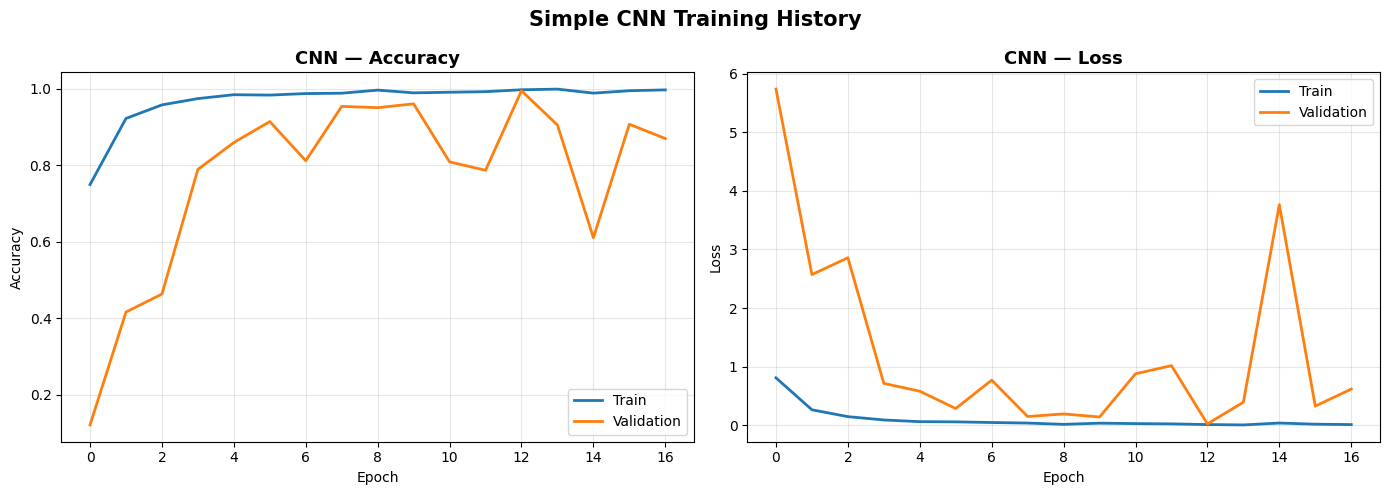

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(cnn_history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('CNN — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(cnn_history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(cnn_history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('CNN — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Simple CNN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 12 — Build Transfer Learning Model (MobileNetV2)

In [13]:
# Load MobileNetV2 pretrained on ImageNet, exclude the top classifier
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base — only train our custom head
base_model.trainable = False
print(f"Base model layers  : {len(base_model.layers)}")
print(f"Trainable params   : {base_model.count_params():,} (all frozen)")

# Build transfer model
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
], name="Transfer_MobileNetV2")

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers  : 154
Trainable params   : 2,257,984 (all frozen)


Model: "Transfer_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## STEP 13 — Train Transfer Learning Model (Phase 1: Frozen Base)

In [14]:
print("Training Transfer Learning model (frozen base)...")

transfer_history = transfer_model.fit(
    train_transfer,
    validation_data=val_transfer,
    epochs=20,
    callbacks=[early_stop, transfer_checkpoint]
)

Training Transfer Learning model (frozen base)...
Epoch 1/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8344 - loss: 0.5695
Epoch 1: val_accuracy improved from None to 0.99433, saving model to /content/best_transfer_model.keras

Epoch 1: finished saving model to /content/best_transfer_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 89s 195ms/step - accuracy: 0.9371 - loss: 0.2176 - val_accuracy: 0.9943 - val_loss: 0.0254
Epoch 2/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9922 - loss: 0.0320
Epoch 2: val_accuracy improved from 0.99433 to 0.99567, saving model to /content/best_transfer_model.keras

Epoch 2: finished saving model to /content/best_transfer_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 65s 29ms/step - accuracy: 0.9921 - loss: 0.0308 - val_accuracy: 0.9957 - val_loss: 0.0158
Epoch 3/20
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9937 - loss: 0.0207
Epoch 3: val_accuracy improved from 0.99567 to 0.99733, saving model to /content/best_transfer_mode

## STEP 14 — Fine-Tuning (Phase 2: Unfreeze Top Layers)
> Unfreeze the last 30 layers of MobileNetV2 and train with a very low learning rate.
> This squeezes extra accuracy out of the model.

In [15]:
# Unfreeze the last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate for fine-tuning
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f" Unfrozen layers in base: {trainable_count}")
print("Fine-tuning Transfer Learning model...")

finetune_history = transfer_model.fit(
    train_transfer,
    validation_data=val_transfer,
    epochs=10,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        transfer_checkpoint
    ]
)

 Unfrozen layers in base: 30
Fine-tuning Transfer Learning model...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9110 - loss: 0.3022
Epoch 1: val_accuracy did not improve from 0.99833
235/235 ━━━━━━━━━━━━━━━━━━━━ 46s 112ms/step - accuracy: 0.9440 - loss: 0.1827 - val_accuracy: 0.9977 - val_loss: 0.0074
Epoch 2/10
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9849 - loss: 0.0517
Epoch 2: val_accuracy did not improve from 0.99833
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9980 - val_loss: 0.0065
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9906 - loss: 0.0281
Epoch 3: val_accuracy did not improve from 0.99833
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9912 - loss: 0.0258 - val_accuracy: 0.9980 - val_loss: 0.0060
Epoch 4/10
233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9949 - loss: 0.0167
Epoch 4: val_accuracy did not improve from 0.99833
235/235 ━━━━━━━━━━━━━━━━

## STEP 15 — Evaluate Transfer Learning Model

In [16]:
transfer_loss, transfer_acc = transfer_model.evaluate(test_transfer, verbose=1)
print(f"\nTransfer Learning Test Accuracy : {transfer_acc * 100:.2f}%")
print(f"   Transfer Learning Test Loss     : {transfer_loss:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.9970 - loss: 0.0079

Transfer Learning Test Accuracy : 99.70%
   Transfer Learning Test Loss     : 0.0079


## STEP 16 — Plot Transfer Learning Training History

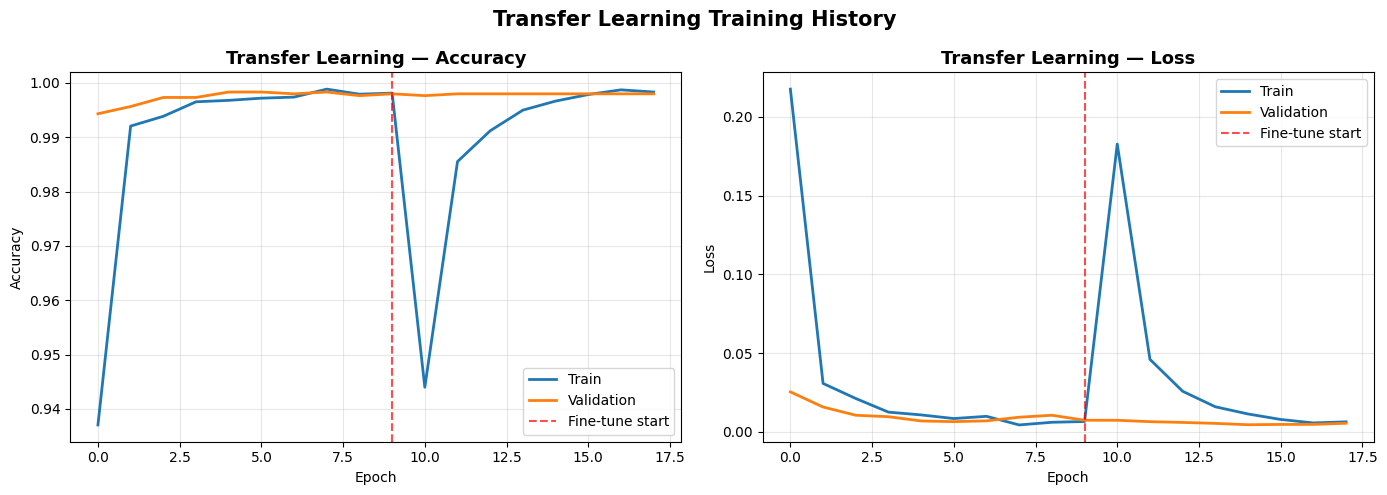

In [17]:
# Combine phase 1 + phase 2 history
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

full_transfer_history = combine_history(transfer_history, finetune_history)
phase1_epochs = len(transfer_history.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(full_transfer_history[metric[0]],     label='Train',      linewidth=2)
    ax.plot(full_transfer_history[metric[1]],     label='Validation', linewidth=2)
    ax.axvline(x=phase1_epochs - 1, color='red', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(f'Transfer Learning — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Transfer Learning Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## STEP 17 — Generate Predictions on Test Set

In [18]:
print("Generating predictions...")

# Predict on full test set at once (fast)
cnn_pred_probs      = cnn_model.predict(test_cnn,      verbose=1)
transfer_pred_probs = transfer_model.predict(test_transfer, verbose=1)

# Get predicted class indices
y_pred_cnn      = np.argmax(cnn_pred_probs, axis=1)
y_pred_transfer = np.argmax(transfer_pred_probs, axis=1)

# Get true labels from test dataset
y_true = np.concatenate([labels.numpy() for _, labels in test_cnn])

print(f"\nTotal test samples : {len(y_true)}")
print("Predictions ready!")

Generating predictions...
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 198ms/step

Total test samples : 3000
Predictions ready!


## STEP 18 — Confusion Matrix: Simple CNN

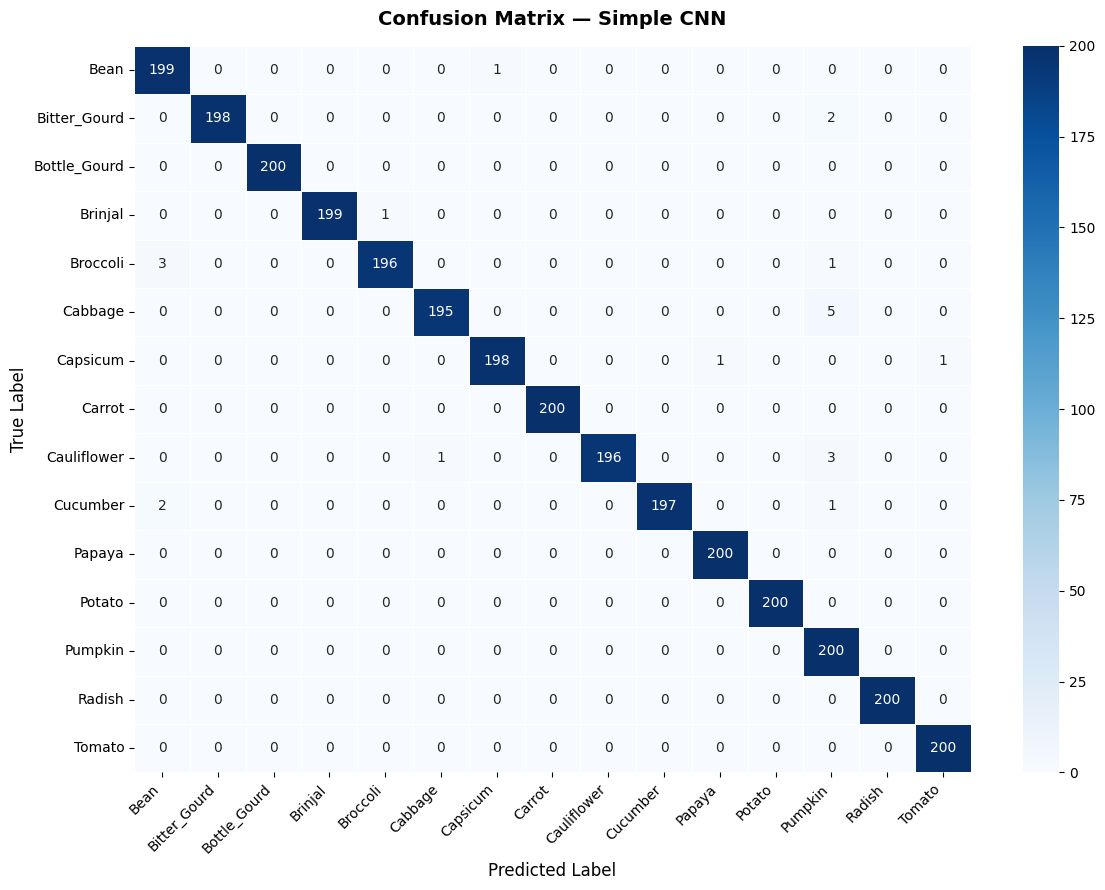

In [19]:
cm_cnn = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — Simple CNN', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## STEP 19 — Confusion Matrix: Transfer Learning

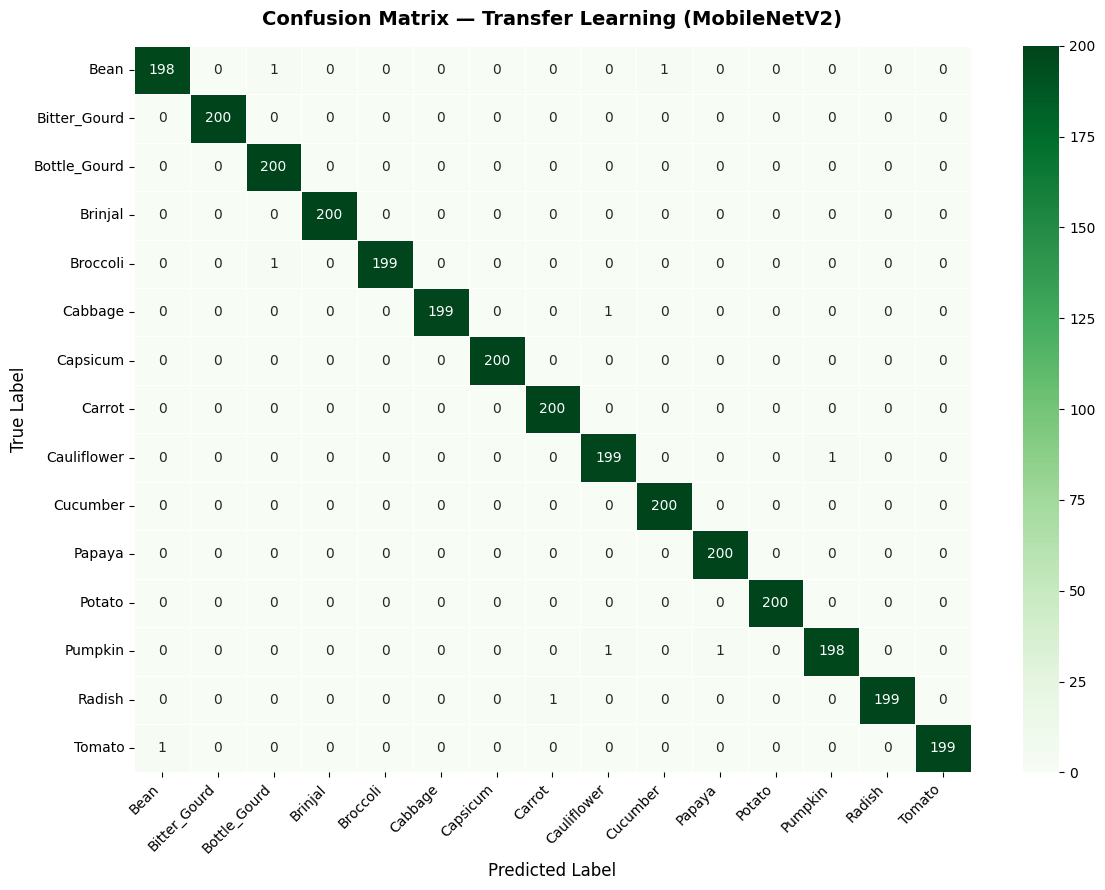

In [20]:
cm_transfer = confusion_matrix(y_true, y_pred_transfer)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm_transfer,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix — Transfer Learning (MobileNetV2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## STEP 20 — Classification Reports

In [21]:
print("=" * 60)
print("         SIMPLE CNN — Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred_cnn, target_names=class_names, digits=4))

print("=" * 60)
print("   TRANSFER LEARNING — Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred_transfer, target_names=class_names, digits=4))

         SIMPLE CNN — Classification Report
              precision    recall  f1-score   support

        Bean     0.9755    0.9950    0.9851       200
Bitter_Gourd     1.0000    0.9900    0.9950       200
Bottle_Gourd     1.0000    1.0000    1.0000       200
     Brinjal     1.0000    0.9950    0.9975       200
    Broccoli     0.9949    0.9800    0.9874       200
     Cabbage     0.9949    0.9750    0.9848       200
    Capsicum     0.9950    0.9900    0.9925       200
      Carrot     1.0000    1.0000    1.0000       200
 Cauliflower     1.0000    0.9800    0.9899       200
    Cucumber     1.0000    0.9850    0.9924       200
      Papaya     0.9950    1.0000    0.9975       200
      Potato     1.0000    1.0000    1.0000       200
     Pumpkin     0.9434    1.0000    0.9709       200
      Radish     1.0000    1.0000    1.0000       200
      Tomato     0.9950    1.0000    0.9975       200

    accuracy                         0.9927      3000
   macro avg     0.9929    0.9927   

## STEP 21 — Final Model Comparison


           FINAL MODEL COMPARISON
  Simple CNN Accuracy      : 99.27%
  Transfer Learning Acc    : 99.70%
  Improvement              : +0.43%


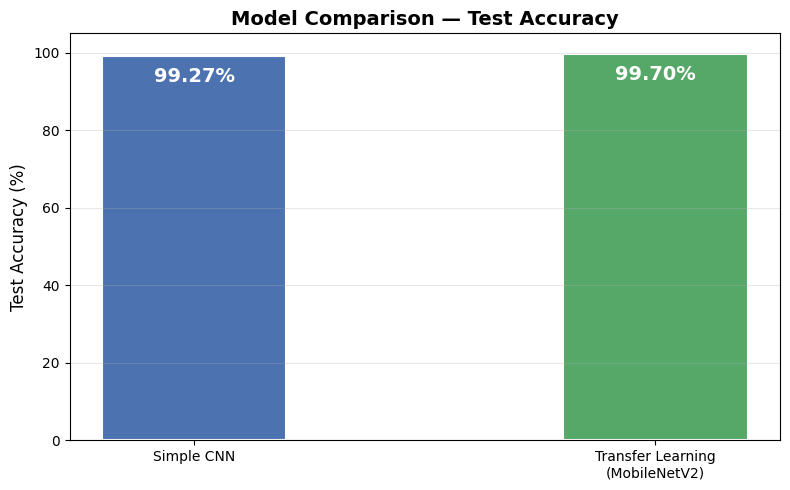

In [22]:
print("\n" + "=" * 45)
print("           FINAL MODEL COMPARISON")
print("=" * 45)
print(f"  Simple CNN Accuracy      : {cnn_acc * 100:.2f}%")
print(f"  Transfer Learning Acc    : {transfer_acc * 100:.2f}%")
print(f"  Improvement              : +{(transfer_acc - cnn_acc) * 100:.2f}%")
print("=" * 45)

# Bar chart comparison
models_names = ['Simple CNN', 'Transfer Learning\n(MobileNetV2)']
accuracies   = [cnn_acc * 100, transfer_acc * 100]
colors       = ['#4C72B0', '#55A868']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_names, accuracies, color=colors, width=0.4, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 3,
             f'{acc:.2f}%',
             ha='center', va='top',
             fontsize=14, fontweight='bold', color='white')
plt.ylim(0, 105)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## STEP 22 — Save Models to Google Drive

In [ ]:
SAVE_DIR = "/content/drive/MyDrive/VegetableModels"
os.makedirs(SAVE_DIR, exist_ok=True)

cnn_model.save(os.path.join(SAVE_DIR, "cnn_model.keras"))
transfer_model.save(os.path.join(SAVE_DIR, "transfer_model.keras"))

print(f"Models saved to: {SAVE_DIR}")
print("   - cnn_model.keras")
print("   - transfer_model.keras")